In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.cluster import KMeans

np.random.seed(42)

print("All packages imported successfully.")

All packages imported successfully.


In [2]:
n = 500

departments = ["Emergency", "Cardiology", "General Medicine", "Orthopedics", "Pediatrics"]
genders = ["Male", "Female"]
day_types = ["Weekday", "Weekend"]

data = pd.DataFrame({
    "Patient_ID": range(1, n + 1),
    "Age": np.random.randint(18, 85, n),
    "Gender": np.random.choice(genders, n),
    "Department": np.random.choice(departments, n),
    "Arrival_Hour": np.random.randint(7, 22, n),
    "Day_Type": np.random.choice(day_types, n, p=[0.75, 0.25]),
    "Queue_Length": np.random.randint(1, 40, n),
    "Staff_Available": np.random.randint(2, 15, n),
    "Consultation_Time": np.random.randint(5, 35, n)
})

department_effect = {
    "Emergency": 15,
    "Cardiology": 10,
    "General Medicine": 6,
    "Orthopedics": 8,
    "Pediatrics": 5
}

data["Waiting_Time"] = (
    5
    + data["Queue_Length"] * 1.8
    - data["Staff_Available"] * 2.2
    + data["Consultation_Time"] * 0.7
    + data["Department"].map(department_effect)
    + np.where(data["Day_Type"] == "Weekend", 8, 0)
    + np.random.normal(0, 8, n)
)

data["Waiting_Time"] = data["Waiting_Time"].clip(lower=5).round(1)

data["Satisfaction_Score"] = (
    100 - data["Waiting_Time"] * 1.2 + np.random.normal(0, 5, n)
).clip(1, 100).round(1)

data.to_csv("smart_hospital_waiting_time.csv", index=False)

data.head()

,Patient_ID,Age,Gender,Department,Arrival_Hour,Day_Type,Queue_Length,Staff_Available,Consultation_Time,Waiting_Time,Satisfaction_Score
0,1,69,Male,Emergency,19,Weekend,16,9,32,58.4,38.7
1,2,32,Male,Orthopedics,15,Weekday,8,6,15,36.8,63.7
2,3,78,Female,Pediatrics,9,Weekend,1,4,29,19.7,74.0
3,4,38,Female,General Medicine,15,Weekday,5,12,5,5.0,93.2
4,5,41,Male,Emergency,8,Weekday,3,8,15,8.3,89.7


In [3]:
print("Dataset shape:", data.shape)

print("\nMissing values:")
print(data.isnull().sum())

print("\nData types:")
print(data.dtypes)

print("\nSummary statistics:")
display(data.describe())

Dataset shape: (500, 11)

Missing values:
Patient_ID            0
Age                   0
Gender                0
Department            0
Arrival_Hour          0
Day_Type              0
Queue_Length          0
Staff_Available       0
Consultation_Time     0
Waiting_Time          0
Satisfaction_Score    0
dtype: int64

Data types:
Patient_ID              int64
Age                     int32
Gender                 object
Department             object
Arrival_Hour            int32
Day_Type               object
Queue_Length            int32
Staff_Available         int32
Consultation_Time       int32
Waiting_Time          float64
Satisfaction_Score    float64
dtype: object

Summary statistics:


,Patient_ID,Age,Arrival_Hour,Queue_Length,Staff_Available,Consultation_Time,Waiting_Time,Satisfaction_Score
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,250.500000,51.146000,14.208000,20.034000,7.880000,19.478000,48.866000,42.240800
std,144.481833,19.821566,4.392188,11.087051,3.859974,8.507542,24.117201,26.968283
min,1.000000,18.000000,7.000000,1.000000,2.000000,5.000000,5.000000,1.000000
25%,125.750000,34.000000,10.000000,10.000000,4.000000,13.000000,32.225000,20.375000
50%,250.500000,51.000000,14.000000,20.000000,8.000000,19.000000,48.200000,41.650000
75%,375.250000,69.000000,18.000000,29.000000,11.000000,27.000000,66.425000,62.100000
max,500.000000,84.000000,21.000000,39.000000,14.000000,34.000000,108.500000,100.000000


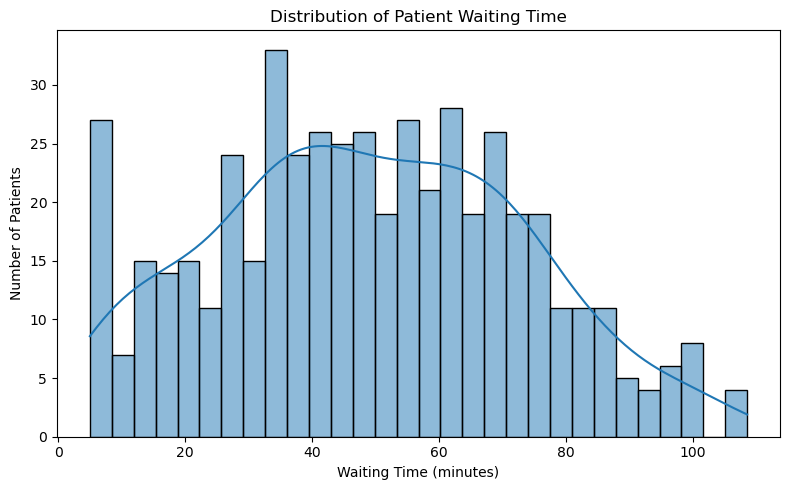

In [4]:
plt.figure(figsize=(8, 5))
sns.histplot(data["Waiting_Time"], bins=30, kde=True)

plt.title("Distribution of Patient Waiting Time")
plt.xlabel("Waiting Time (minutes)")
plt.ylabel("Number of Patients")

plt.tight_layout()
plt.savefig("fig1_waiting_time_distribution.png", dpi=300)
plt.show()

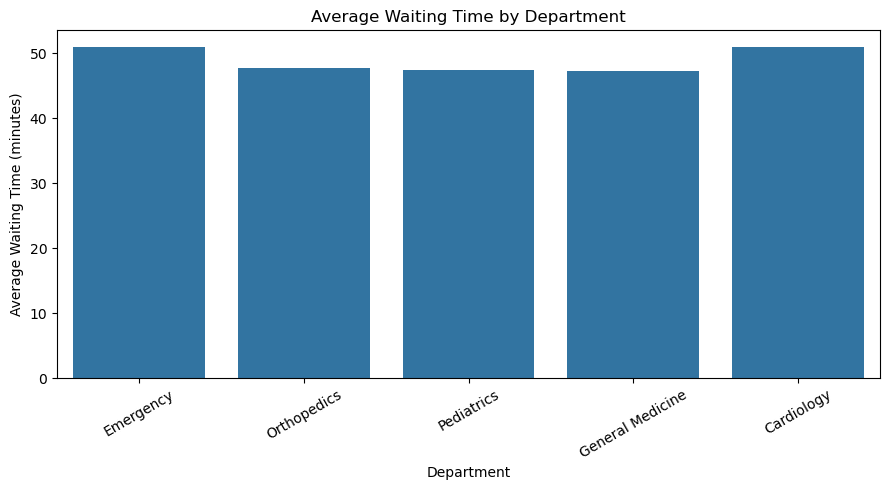

In [5]:
plt.figure(figsize=(9, 5))
sns.barplot(x="Department", y="Waiting_Time", data=data, errorbar=None)

plt.title("Average Waiting Time by Department")
plt.xlabel("Department")
plt.ylabel("Average Waiting Time (minutes)")
plt.xticks(rotation=30)

plt.tight_layout()
plt.savefig("fig2_waiting_time_by_department.png", dpi=300)
plt.show()

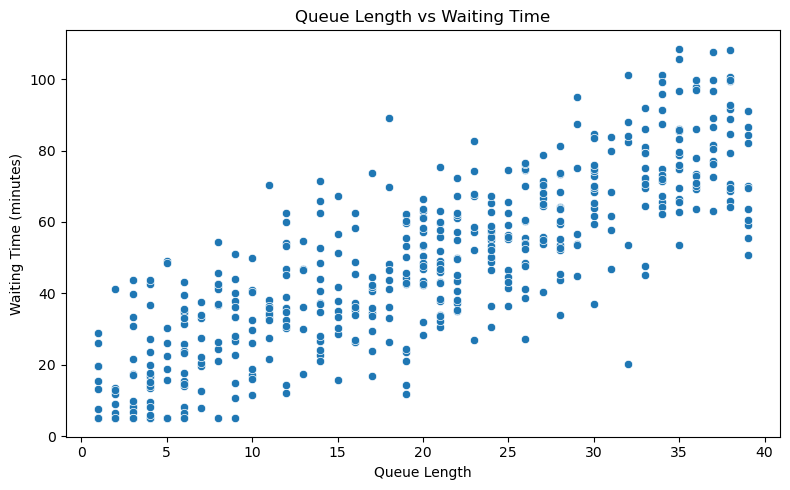

In [6]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x="Queue_Length", y="Waiting_Time", data=data)

plt.title("Queue Length vs Waiting Time")
plt.xlabel("Queue Length")
plt.ylabel("Waiting Time (minutes)")

plt.tight_layout()
plt.savefig("fig3_queue_vs_waiting_time.png", dpi=300)
plt.show()

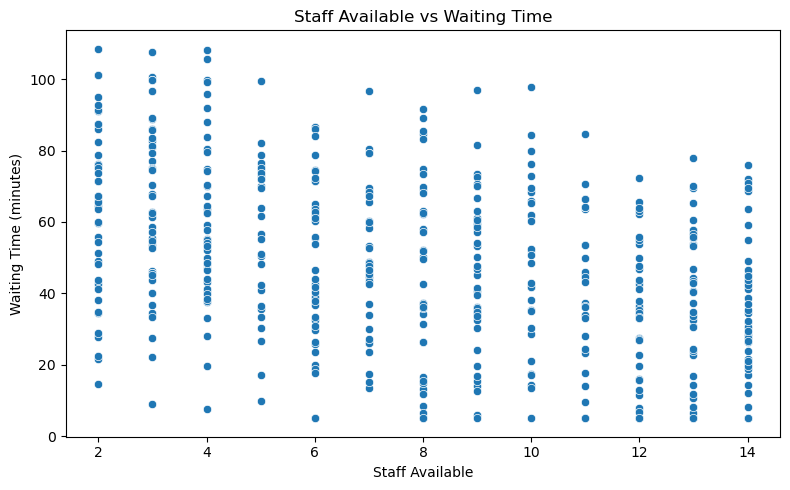

In [7]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x="Staff_Available", y="Waiting_Time", data=data)

plt.title("Staff Available vs Waiting Time")
plt.xlabel("Staff Available")
plt.ylabel("Waiting Time (minutes)")

plt.tight_layout()
plt.savefig("fig4_staff_vs_waiting_time.png", dpi=300)
plt.show()

In [8]:
X = data[[
    "Age",
    "Gender",
    "Department",
    "Arrival_Hour",
    "Day_Type",
    "Queue_Length",
    "Staff_Available",
    "Consultation_Time"
]]

y = data["Waiting_Time"]

categorical_features = ["Gender", "Department", "Day_Type"]
numeric_features = ["Age", "Arrival_Hour", "Queue_Length", "Staff_Available", "Consultation_Time"]

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(drop="first"), categorical_features),
        ("num", "passthrough", numeric_features)
    ]
)

regression_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression())
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

regression_model.fit(X_train, y_train)

y_pred = regression_model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Regression Results")
print("MSE:", round(mse, 2))
print("RMSE:", round(rmse, 2))
print("R2 Score:", round(r2, 3))

Regression Results
MSE: 65.39
RMSE: 8.09
R2 Score: 0.878


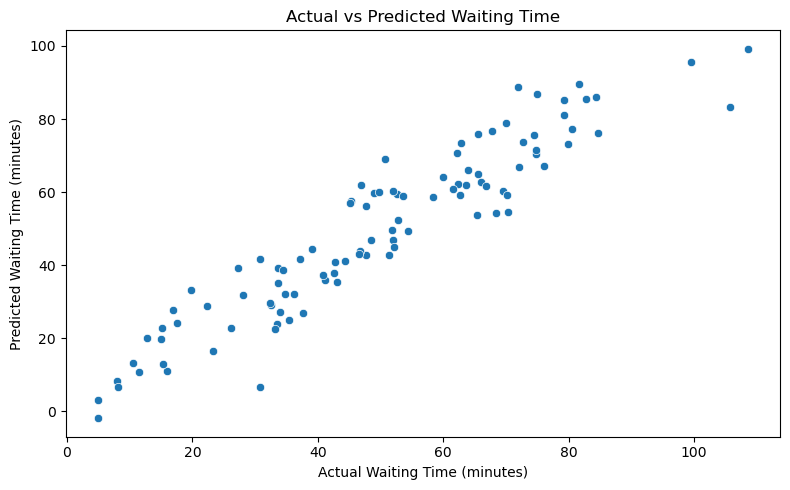

In [9]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x=y_test, y=y_pred)

plt.title("Actual vs Predicted Waiting Time")
plt.xlabel("Actual Waiting Time (minutes)")
plt.ylabel("Predicted Waiting Time (minutes)")

plt.tight_layout()
plt.savefig("fig5_actual_vs_predicted_waiting_time.png", dpi=300)
plt.show()

In [10]:
cluster_features = data[[
    "Queue_Length",
    "Staff_Available",
    "Consultation_Time",
    "Waiting_Time"
]]

scaler = StandardScaler()
cluster_scaled = scaler.fit_transform(cluster_features)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
data["Cluster"] = kmeans.fit_predict(cluster_scaled)

cluster_summary = data.groupby("Cluster")[[
    "Queue_Length",
    "Staff_Available",
    "Consultation_Time",
    "Waiting_Time",
    "Satisfaction_Score"
]].mean().round(2)

print("Cluster Summary")
display(cluster_summary)

Cluster Summary


D:\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


,Queue_Length,Staff_Available,Consultation_Time,Waiting_Time,Satisfaction_Score
Cluster,,,,,
0,30.71,6.16,19.21,72.72,15.84
1,12.83,9.27,12.18,27.02,66.83
2,14.29,8.57,27.44,42.06,49.34


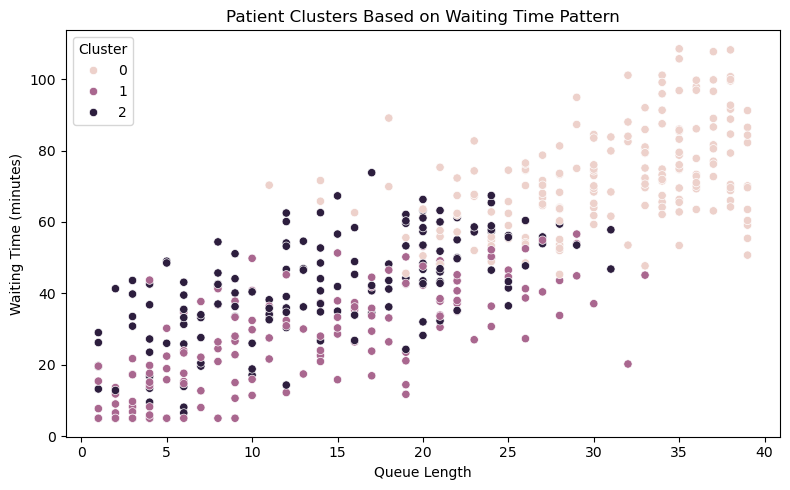

In [11]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    x="Queue_Length",
    y="Waiting_Time",
    hue="Cluster",
    data=data
)

plt.title("Patient Clusters Based on Waiting Time Pattern")
plt.xlabel("Queue Length")
plt.ylabel("Waiting Time (minutes)")
plt.legend(title="Cluster")

plt.tight_layout()
plt.savefig("fig6_patient_clusters.png", dpi=300)
plt.show()

In [12]:
data.to_csv("smart_hospital_waiting_time_with_clusters.csv", index=False)

print("Files saved successfully:")
print("1. smart_hospital_waiting_time.csv")
print("2. smart_hospital_waiting_time_with_clusters.csv")
print("3. fig1_waiting_time_distribution.png")
print("4. fig2_waiting_time_by_department.png")
print("5. fig3_queue_vs_waiting_time.png")
print("6. fig4_staff_vs_waiting_time.png")
print("7. fig5_actual_vs_predicted_waiting_time.png")
print("8. fig6_patient_clusters.png")

Files saved successfully:
1. smart_hospital_waiting_time.csv
2. smart_hospital_waiting_time_with_clusters.csv
3. fig1_waiting_time_distribution.png
4. fig2_waiting_time_by_department.png
5. fig3_queue_vs_waiting_time.png
6. fig4_staff_vs_waiting_time.png
7. fig5_actual_vs_predicted_waiting_time.png
8. fig6_patient_clusters.png
